Using device: cuda
Using device: cuda
Generating training data...
Data loaded: 5000 points, Batch size: 64

Model and Optimizer Initialized.
MechanismNN(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=4, bias=True)
)

Starting training...
Epoch [1/10], Loss: 18.369554
Epoch [2/10], Loss: 9.159962
Epoch [4/10], Loss: 5.931212
Epoch [6/10], Loss: 21.396718
Epoch [8/10], Loss: 22.529955
Epoch [10/10], Loss: 22.465113

Training finished in 185.97 seconds


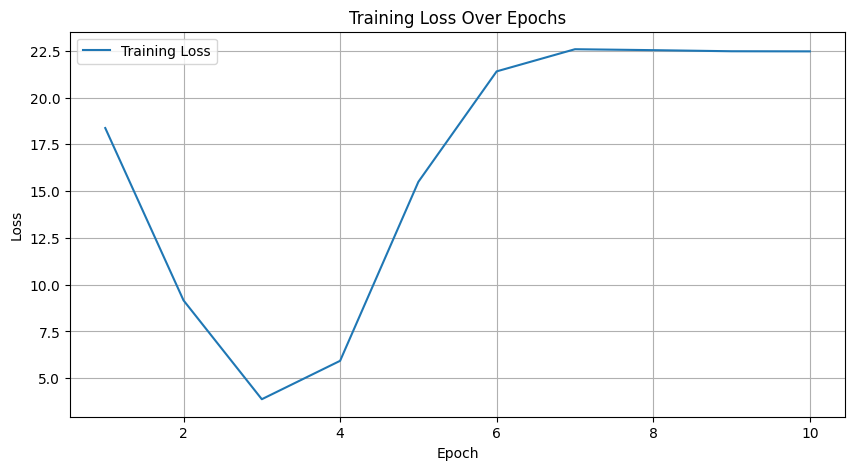

In [ ]:
# train_mechanism_nn.py

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import math
import time
import matplotlib.pyplot as plt # Optional for plotting data

#torch.autograd.set_detect_anomaly(True) 

# --- Configuration ---
# Data Generation
NUM_POINTS = 5000
X_MIN, X_MAX = -4.0, 1.0
Y_MIN, Y_MAX = 1.0, 7.0

# Training Hyperparameters
NUM_EPOCHS = 10
BATCH_SIZE = 64  
LEARNING_RATE = 1e-4 # Starting learning rate
PRINT_EVERY = 2   # Print loss every X epochs

# Simulation/Loss Parameters
NUM_SIM_STEPS = 73 # ~5 degrees steps (inclusive endpoint for linspace)
LAMBDA_GRASHOF = 20.0 # Penalty weight if not crank-rocker
LAMBDA_CRANK_SIZE = 0.1 # Penalty weight for large crank size (l2)
LAMBDA_ASSEMBLY = 50.0 # Base penalty weight for low assembly success ratio

# --- Device Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Helper Function for Constraints ---

def check_crank_rocker(l1, l2, l3, l4):
    """Checks Grashof and Crank-Rocker condition using PyTorch tensors."""
    l1_t = torch.as_tensor(l1).to(l2.device) # Ensure tensor and on correct device
    l2_t = torch.as_tensor(l2).to(l2.device)
    l3_t = torch.as_tensor(l3).to(l2.device)
    l4_t = torch.as_tensor(l4).to(l2.device)

    if l1_t.ndim == 0: 
         lengths = torch.stack([l1_t, l2_t, l3_t, l4_t], dim=-1) 
    else: 
         lengths = torch.stack([l1_t, l2_t, l3_t, l4_t], dim=-1) 

    ls_sorted, _ = torch.sort(lengths, dim=-1)
    s = ls_sorted[..., 0]; p = ls_sorted[..., 1]; q = ls_sorted[..., 2]; l = ls_sorted[..., 3]
    grashof_satisfied = (s + l <= p + q + 1e-6) # Add epsilon for stability
    is_crank_shortest = torch.isclose(l2_t, s)
    is_crank_rocker = grashof_satisfied & is_crank_shortest
    return is_crank_rocker

# --- PyTorch Simulation Function ---

def simulate_four_bar_coupler_point_torch(l1, l2, l3, l4, theta2_rad, 
                                           S_ratio=0.5,
                                           bar_length=1.5,
                                           bar_angle_offset=math.pi/2):
    """Calculates the position of the coupler point P using PyTorch."""
    dtype = theta2_rad.dtype
    device = theta2_rad.device
    l1 = torch.as_tensor(l1, dtype=dtype, device=device)
    l2 = torch.as_tensor(l2, dtype=dtype, device=device)
    l3 = torch.as_tensor(l3, dtype=dtype, device=device)
    l4 = torch.as_tensor(l4, dtype=dtype, device=device)

    Px = torch.full_like(theta2_rad, float('nan'))
    Py = torch.full_like(theta2_rad, float('nan'))
    Ax = l2 * torch.cos(theta2_rad); Ay = l2 * torch.sin(theta2_rad)
    d_sq = (Ax - l1)**2 + Ay**2
    epsilon = 1e-12 
    d = torch.where(d_sq > epsilon, torch.sqrt(d_sq), torch.tensor(float('nan'), dtype=dtype, device=device))

    cos_phi_arg = torch.full_like(d, float('nan'))
    cos_psi_arg = torch.full_like(d, float('nan'))
    valid_d_mask = ~torch.isnan(d) & (d > epsilon) & (l3 > epsilon) & (l4 > epsilon)

    if torch.any(valid_d_mask):
        d_valid = d[valid_d_mask]; d_sq_valid = d_sq[valid_d_mask]
        safe_denom_phi = 2 * d_valid * l4 + epsilon
        safe_denom_psi = 2 * d_valid * l3 + epsilon
        cos_phi_arg[valid_d_mask] = (d_sq_valid + l4**2 - l3**2) / safe_denom_phi
        cos_psi_arg[valid_d_mask] = (d_sq_valid + l3**2 - l4**2) / safe_denom_psi

    valid_assembly_mask = valid_d_mask & (torch.abs(cos_phi_arg) <= 1.0 + epsilon) & (torch.abs(cos_psi_arg) <= 1.0 + epsilon) 

    if torch.any(valid_assembly_mask):
        Ax_valid = Ax[valid_assembly_mask]; Ay_valid = Ay[valid_assembly_mask]
        cos_phi_arg_valid = cos_phi_arg[valid_assembly_mask]
        safe_cos_phi_arg = torch.clip(cos_phi_arg_valid, -1.0, 1.0)
        phi = torch.acos(safe_cos_phi_arg)
        alpha = torch.atan2(Ay_valid - 0, Ax_valid - l1) 
        theta4 = alpha - phi 
        Bx = l1 + l4 * torch.cos(theta4)
        By = l4 * torch.sin(theta4)
        theta3 = torch.atan2(By - Ay_valid, Bx - Ax_valid)
        Sx = Ax_valid + S_ratio * (Bx - Ax_valid)
        Sy = Ay_valid + S_ratio * (By - Ay_valid)
        angle_term = theta3 + bar_angle_offset
        Px_update = Sx + bar_length * torch.cos(angle_term)
        Py_update = Sy + bar_length * torch.sin(angle_term)
        Px[valid_assembly_mask] = Px_update
        Py[valid_assembly_mask] = Py_update
    return Px, Py

# --- Neural Network Definition ---

class MechanismNN(nn.Module):
    """Neural network to predict four-bar linkage parameters."""
    def __init__(self):
        super(MechanismNN, self).__init__()
        self.fc1 = nn.Linear(2, 264)
        self.fc2 = nn.Linear(264, 264)
        self.fc3 = nn.Linear(264, 264)
        self.fc4 = nn.Linear(264, 264)
        self.fc5 = nn.Linear(264, 4)

    def forward(self, x):
        """Forward pass."""
        x = F.relu(self.fc1(x)); x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x)); x = F.relu(self.fc4(x))
        x = F.softplus(self.fc5(x)) # Output positive link lengths
        return x

# --- Custom Loss Function ---

def compute_mechanism_loss(predicted_lengths, target_points,
                           sim_func=simulate_four_bar_coupler_point_torch,
                           num_sim_steps=NUM_SIM_STEPS, 
                           lambda_grashof=LAMBDA_GRASHOF,
                           lambda_crank_size=LAMBDA_CRANK_SIZE,
                           lambda_assembly=LAMBDA_ASSEMBLY):
    """Computes the custom loss for a batch of predicted mechanisms."""
    batch_size = predicted_lengths.shape[0]
    device = predicted_lengths.device
    dtype = predicted_lengths.dtype
    theta2_range = torch.linspace(0, 2 * math.pi, num_sim_steps, dtype=dtype, device=device)
    batch_losses = [] 

    for i in range(batch_size):
        l1, l2, l3, l4 = predicted_lengths[i] 
        target_point = target_points[i]     
        x_target, y_target = target_point[0], target_point[1]
        epsilon_len = 1e-6 # Prevent exactly zero lengths
        l1 = l1 + epsilon_len; l2 = l2 + epsilon_len; l3 = l3 + epsilon_len; l4 = l4 + epsilon_len
        
        Px_path, Py_path = sim_func(l1, l2, l3, l4, theta2_range)
        
        valid_path_mask = ~torch.isnan(Px_path)
        assembly_success_ratio = valid_path_mask.float().mean()

        if torch.any(valid_path_mask):
            Px_valid = Px_path[valid_path_mask]; Py_valid = Py_path[valid_path_mask]
            sq_distances = (Px_valid - x_target)**2 + (Py_valid - y_target)**2
            min_dist = torch.sqrt(torch.min(sq_distances)) # Use sqrt distance
            loss_dist = min_dist
        else:
            loss_dist = torch.tensor(100.0, dtype=dtype, device=device) 

        is_cr = check_crank_rocker(l1, l2, l3, l4)
        penalty_grashof = torch.where(is_cr, torch.tensor(0.0, dtype=dtype, device=device), torch.tensor(lambda_grashof, dtype=dtype, device=device))
        penalty_crank = lambda_crank_size * l2
        assembly_penalty = torch.where(assembly_success_ratio < 0.8, torch.tensor(lambda_assembly, dtype=dtype, device=device) * (1.0 - assembly_success_ratio), torch.tensor(0.0, dtype=dtype, device=device))

        loss_item = loss_dist + penalty_grashof + penalty_crank + assembly_penalty
        batch_losses.append(loss_item)

    if batch_losses: 
        total_loss = torch.mean(torch.stack(batch_losses))
    else:
        total_loss = torch.tensor(0.0, dtype=dtype, device=device, requires_grad=True) 
    return total_loss

# --- Data Generation Function ---

def generate_target_points(num_points, x_min, x_max, y_min, y_max, dtype=torch.float32):
    """Generates random target points uniformly within specified boundaries."""
    rand_tensor = torch.rand(num_points, 2, dtype=dtype) 
    x_coords = rand_tensor[:, 0] * (x_max - x_min) + x_min
    y_coords = rand_tensor[:, 1] * (y_max - y_min) + y_min
    target_points = torch.stack((x_coords, y_coords), dim=1) 
    return target_points

# --- Main Execution ---

if __name__ == '__main__':

    # --- Device Setup --- #
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 1. Generate Data and Create DataLoader
    print("Generating training data...")
    training_target_points = generate_target_points(NUM_POINTS, X_MIN, X_MAX, Y_MIN, Y_MAX)
    dataset = TensorDataset(training_target_points) 
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0) # num_workers=0 for simplicity often needed on Windows/macOS interactive
    print(f"Data loaded: {len(dataset)} points, Batch size: {BATCH_SIZE}")

    # Optional: Visualize Data
    # plt.figure(); plt.scatter(training_target_points[:,0].numpy(), training_target_points[:,1].numpy(), s=5); plt.show()

    # 2. Initialize Model and Optimizer
    model = MechanismNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    print("\nModel and Optimizer Initialized.")
    print(model)

    # 3. Training Loop
    print("\nStarting training...")
    start_time = time.time()
    training_losses = [] # Store losses for potential plotting

    for epoch in range(NUM_EPOCHS):
        model.train() 
        epoch_loss = 0.0
        num_batches = 0

        for batch_idx, (batch_target_points,) in enumerate(dataloader): 
            batch_target_points = batch_target_points.to(device)
            
            optimizer.zero_grad()
            predicted_lengths = model(batch_target_points)
            loss = compute_mechanism_loss(predicted_lengths, batch_target_points)
            loss.backward()
            # Optional: Gradient clipping if gradients explode
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
            optimizer.step()
            
            epoch_loss += loss.item() 
            num_batches += 1
            
        avg_epoch_loss = epoch_loss / num_batches
        training_losses.append(avg_epoch_loss)
        
        if (epoch + 1) % PRINT_EVERY == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_epoch_loss:.6f}")

    end_time = time.time()
    print(f"\nTraining finished in {end_time - start_time:.2f} seconds")

    # 4. Save the Trained Model (Optional)
    # model_save_path = 'mechanism_nn_model.pth'
    # torch.save(model.state_dict(), model_save_path)
    # print(f"Model state dictionary saved to {model_save_path}")

    #5. Plot Training Loss (Optional)
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, NUM_EPOCHS + 1), training_losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 6. Example: Test the trained model on a new point (Optional)
    # model.eval() # Set model to evaluation mode
    # test_point = torch.tensor([[-1.0, 4.0]], dtype=torch.float32).to(device) # Example test point
    # with torch.no_grad():
    #     final_lengths = model(test_point)
    # print("\nExample prediction for test point [-1.0, 4.0]:")
    # print(final_lengths.cpu().numpy())
    # # You could then simulate these lengths and plot the result